**BÀI THỰC HÀNH 2 - PHÂN LỚP VĂN BẢN VỚI NEURAL NETWORK**

NỘI DUNG:

*   SỬ DỤNG PYTORCH
*   SỬ DỤNG TRAINER


In [ ]:
pip install kagglehub scikit-learn transformers evaluate matplotlib numpy pandas nltk seaborn torch datasets

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import kagglehub
import os
import shutil
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")


source_file = os.path.join(path, "spam.csv")
destination_file = "spam.csv" # Save to the current directory

shutil.copy(source_file, destination_file)

'spam.csv'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import re # Regular Expression

import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.metrics import precision_score, recall_score, classification_report, accuracy_score, f1_score, ConfusionMatrixDisplay
from sklearn import metrics

import seaborn as sns #Charts

import torch
import torch.nn as nn
import torch.nn.functional as F

from datasets import Dataset

from transformers import Trainer, TrainingArguments

import evaluate

nltk.download('punkt_tab')
nltk.download('stopwords')
download_dir = os.path.join(os.getcwd(), 'nltk_data')
os.makedirs(download_dir, exist_ok=True)

nltk.download('punkt', download_dir=download_dir)
nltk.download('stopwords', download_dir=download_dir)

nltk.data.path.append(download_dir)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     d:\Daniel_Nguyen\UIT_HK6\CS221 - XỬ LÝ NGÔN NGỮ TỰ
[nltk_data]     NHIÊN\ThucHanh\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     d:\Daniel_Nguyen\UIT_HK6\CS221 - XỬ LÝ NGÔN NGỮ TỰ
[nltk_data]     NHIÊN\ThucHanh\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
spamdata = pd.read_csv("spam.csv", encoding="windows-1252")
spamdata.info()
spamdata = spamdata.drop(spamdata[["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"]], axis=1)
spamdata.rename(columns = {"v1":"Class", "v2":"Message"}, inplace = True)
spamdata.head()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


,Class,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Text(0, 0.5, 'Số mẫu')

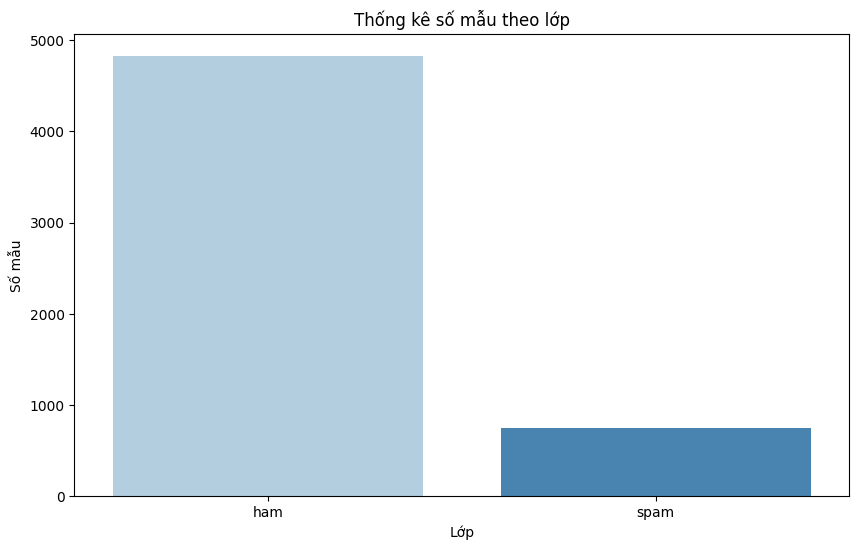

In [ ]:

cols= sns.color_palette("Blues", n_colors=2)

plt.figure(figsize=(10,6))
fig = sns.countplot(data=spamdata, x='Class', hue="Class", palette= cols, legend=False)
fig.set_title("Thống kê số mẫu theo lớp", color="#000000")
fig.set_xlabel("Lớp")
fig.set_ylabel("Số mẫu")

Tiền xử lý dữ liệu, ở đây là các SMS. Chúng ta sẽ thực hiện:

- Loại bỏ các ký tự không phải bộ chữ cái.
- Chuyển thành chữ thường
- Loại bỏ khoảng trắng thừa.

(Các bạn có thể tiền xử lý với những bước xử lý khác, phù hợp với bài toán)

In [ ]:
def Preprocess(Text):
    sms = re.sub('[^a-zA-Z]', ' ', Text)
    sms = sms.lower()
    sms = sms.split()
    sms = ' '.join(sms)
    return sms

spamdata["PrepMessage"] = spamdata["Message"].apply(Preprocess)
print(*spamdata["PrepMessage"][:5], sep = "\n")

go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat
ok lar joking wif u oni
free entry in a wkly comp to win fa cup final tkts st may text fa to to receive entry question std txt rate t c s apply over s
u dun say so early hor u c already then say
nah i don t think he goes to usf he lives around here though


Sau đó, chúng ta sẽ thực hiện vector hóa các SMS của bộ ngữ liệu, thành một tập các vectors. Trong phần này, chúng ta dùng lớp TfidfVectorizer và lớp LabelEncoder.

In [ ]:
corpus = list(spamdata["PrepMessage"])
tfidf = TfidfVectorizer()
vectors = tfidf.fit_transform(corpus).toarray()

print(vectors.shape)
label_encoder = LabelEncoder()
spamdata["Class"] = label_encoder.fit_transform(spamdata["Class"])
print(spamdata["Class"][:5])

(5572, 7682)
0    0
1    0
2    1
3    0
4    0
Name: Class, dtype: int64


Chúng ta bắt đầu chia dữ liệu thành các tập Train và Test. Trong đó, kích thước tập Train bằng 80% kích thước tập mẫu, và kích thước tập Test bằng 20% kích thước tập mẫu. Tập Train gồm Trainvecs chứa các vector đầu vào và Trainclss chứa các nhãn tương ứng. Tập Test gồm Testvecs chứa các vector đầu vào và Testclss chứa các nhãn tương ứng.

In [ ]:
classes = spamdata["Class"]

Trainvecs, Testvecs, Trainclss, Testclss = train_test_split(vectors, classes, test_size=0.2, random_state=42)

Tiếp theo, chúng ta thiết kế một lớp mô tả kiến trúc mạng nơron để huấn luyện một mô hình phân lớp.

In [ ]:
class Classifier(nn.Module):
  def __init__(self, input_size, nclass):
    super().__init__()
    self.fc = nn.Linear(input_size, nclass) #Tự tạo một kiến trúc mạng đơn giản với một lớp fully connected
    self.loss_func = nn.CrossEntropyLoss()

  def forward(self, features, labels=None):
    logits = self.fc(features)
    loss = None
    if labels != None:
      loss = self.loss_func(logits, labels) #Tính loss nếu có nhãn, sử dụng CrossEntropyLoss cho bài toán phân loại
    return {"loss": loss, "logits": logits}

In [ ]:
trainset = Dataset.from_dict({"features": Trainvecs, "labels": Trainclss})
testset = Dataset.from_dict({"features": Testvecs, "labels": Testclss})

trainset.set_format(type="torch", columns=["features", "labels"])
testset.set_format(type="torch", columns=["features", "labels"])

In [ ]:
from transformers import Trainer, TrainingArguments
training_args = TrainingArguments(
    dataloader_pin_memory=False, #Tắt tính năng pin_memory để tránh lỗi khi sử dụng GPU
    output_dir="results",
    learning_rate=0.05,
    per_device_train_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch", #Đánh giá sau mỗi epoch để theo dõi hiệu suất trên tập kiểm tra
    logging_strategy="epoch", #Ghi log sau mỗi epoch để theo dõi quá trình huấn luyện
    save_strategy="epoch", #Lưu mô hình sau mỗi epoch để có thể khôi phục hoặc đánh giá sau này
    report_to="none", #Không gửi báo cáo đến bất kỳ hệ thống theo dõi nào (như TensorBoard, WandB, v.v.
)


def compute_metrics(results): #Hàm này sẽ được gọi sau mỗi lần đánh giá để tính toán các chỉ số hiệu suất như accuracy, precision, recall và f1-score dựa trên kết quả dự đoán và nhãn thực tế.
  pred, targ = results #Chứa 2 thành phần: pred là kết quả dự đoán của mô hình (dạng logits) và targ là nhãn thực tế. Hàm này sẽ sử dụng các thư viện đánh giá để tính toán các chỉ số hiệu suất dựa trên những kết quả này.
  pred = np.argmax(pred, axis=-1)
  res = {}
  metric = evaluate.load("accuracy")
  res["accuracy"] = metric.compute(predictions=pred, references=targ)["accuracy"]
  metric = evaluate.load("precision")
  res["precision"] = metric.compute(predictions=pred, references=targ)["precision"]
  metric = evaluate.load("recall")
  res["recall"] = metric.compute(predictions=pred, references=targ)["recall"]
  metric = evaluate.load("f1")
  res["f1"] = metric.compute(predictions=pred, references=targ)["f1"]
  return res #Trả về một dictionary chứa các chỉ số hiệu suất đã tính toán, có thể được sử dụng để theo dõi và đánh giá mô hình trong quá trình huấn luyện.
#metric duyệt qua từng chỉ số hiệu suất (accuracy, precision, recall, f1) và sử dụng thư viện evaluate để tính toán giá trị của từng chỉ số dựa trên kết quả dự đoán và nhãn thực tế. 
#Kết quả cuối cùng được trả về dưới dạng một dictionary chứa tất cả các chỉ số đã tính toán.

ImportError: Using the `Trainer` with `PyTorch` requires `accelerate>=1.1.0`: Please run `pip install transformers[torch]` or `pip install 'accelerate>=1.1.0'`

In [ ]:
model = Classifier(len(Trainvecs[0]), 2) #Xác định chiều của vector đầu vào dựa trên số lượng đặc trưng (features) và số lớp (nclass) là 2 (spam và ham)
allparams = sum(p.numel() for p in model.parameters())
trainparams = sum(p.numel() for p in model.parameters() if p.requires_grad)
#tham số có requies_grad=True sẽ được cập nhật trong quá trình huấn luyện, trong khi các tham số khác có thể là các tham số cố định hoặc không được cập nhật.
print("All Param:", allparams, "Train Params:", trainparams)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=trainset,
    eval_dataset=testset, #Cung cấp tập dữ liệu kiểm tra để đánh giá hiệu suất của mô hình sau mỗi epoch
    compute_metrics=compute_metrics, #Hiển thị các chỉ số hiệu suất sau mỗi lần đánh giá để theo dõi quá trình huấn luyện và cải thiện mô hình nếu cần thiết
)

trainer.train()

All Param: 15366 Train Params: 15366


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.101049,0.067443,0.980269,0.984848,0.866667,0.921986
2,0.018835,0.069384,0.980269,0.984848,0.866667,0.921986
3,0.010266,0.067127,0.981166,0.984962,0.873333,0.925795
4,0.007712,0.069829,0.981166,0.984962,0.873333,0.925795
5,0.006399,0.069332,0.981166,0.984962,0.873333,0.925795


TrainOutput(global_step=2790, training_loss=0.028852250670019442, metrics={'train_runtime': 15.3976, 'train_samples_per_second': 1447.307, 'train_steps_per_second': 181.198, 'total_flos': 0.0, 'train_loss': 0.028852250670019442, 'epoch': 5.0})